#Importing

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [3]:
data=pd.read_csv('/content/customer_segmentation.csv')
data.head(10)

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,88,546,172,88,88,3,8,10,4,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,1,6,2,1,6,2,1,1,2,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,49,127,111,21,42,1,8,2,10,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,4,20,10,3,5,2,2,0,4,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,43,118,46,27,15,5,5,3,6,5,0,0,0,0,0,0,3,11,0
5,7446,1967,Master,Together,62513.0,0,1,09-09-2013,16,520,42,98,0,42,14,2,6,4,10,6,0,0,0,0,0,0,3,11,0
6,965,1971,Graduation,Divorced,55635.0,0,1,13-11-2012,34,235,65,164,50,49,27,4,7,3,7,6,0,0,0,0,0,0,3,11,0
7,6177,1985,PhD,Married,33454.0,1,0,08-05-2013,32,76,10,56,3,1,23,2,4,0,4,8,0,0,0,0,0,0,3,11,0
8,4855,1974,PhD,Together,30351.0,1,0,06-06-2013,19,14,0,24,3,3,2,1,3,0,2,9,0,0,0,0,0,0,3,11,1
9,5899,1950,PhD,Together,5648.0,1,1,13-03-2014,68,28,0,6,1,1,13,1,1,0,0,20,1,0,0,0,0,0,3,11,0


In [4]:
data.info()
#(2240,29)
#i see a null containing column

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   i

In [5]:
data.isnull().sum()
data.columns
data.dropna(inplace=True)
data.isnull().sum().sum()
#as we the ratio of missing data to given data is very small we wont really face a
#problem of exclusion bias is minimal

np.int64(0)

In [6]:
data["Education"].value_counts()

,count
Education,
Graduation,1116
PhD,481
Master,365
2n Cycle,200
Basic,54


In [7]:
data['Marital_Status'].value_counts()

,count
Marital_Status,
Married,857
Together,573
Single,471
Divorced,232
Widow,76
Alone,3
Absurd,2
YOLO,2


In [8]:
data["Dt_Customer"]= pd.to_datetime(data["Dt_Customer"],dayfirst=True)

In [9]:
data["Age"]=2026-data['Year_Birth']
data["Totchild"]=data["Teenhome"]+data["Kidhome"]

In [10]:
data.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1',
       'AcceptedCmp2', 'Complain', 'Z_CostContact', 'Z_Revenue', 'Response',
       'Age', 'Totchild'],
      dtype='object')

In [11]:
ssd=['MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts']
data["Spending"]=data[ssd].sum(axis=1)

In [12]:
data[["Income","Spending"]]
data["Customer_since"]=(pd.Timestamp("today")-data["Dt_Customer"]).dt.days

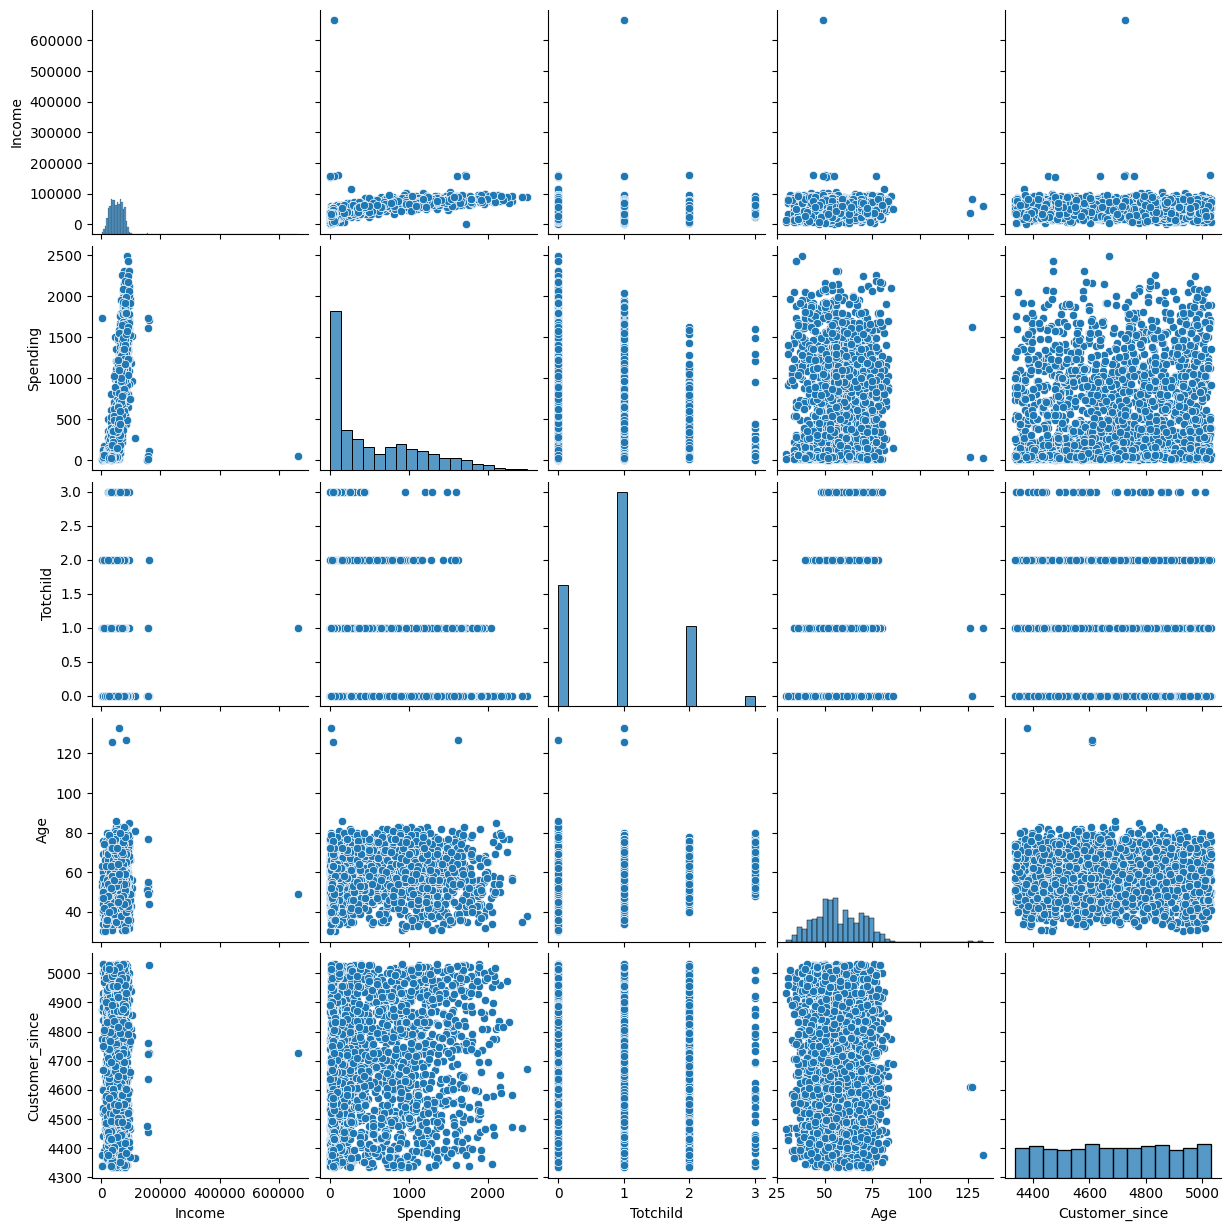

In [13]:
sns.pairplot(data[["Income","Spending","Totchild","Age","Customer_since"]])
plt.show()


<Axes: xlabel='Age', ylabel='Count'>

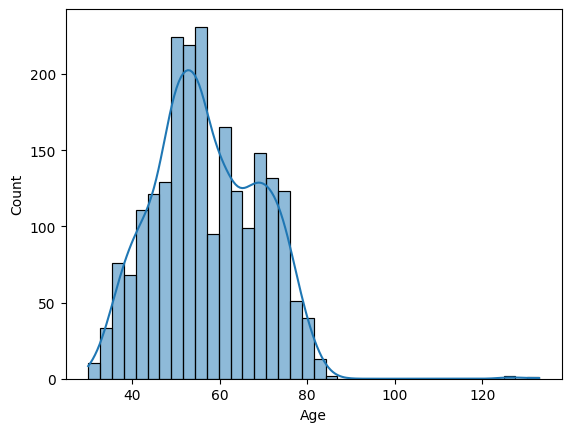

In [14]:
sns.histplot(data["Age"],kde=True)
#Mean is around 50

<Axes: xlabel='Education', ylabel='Count'>

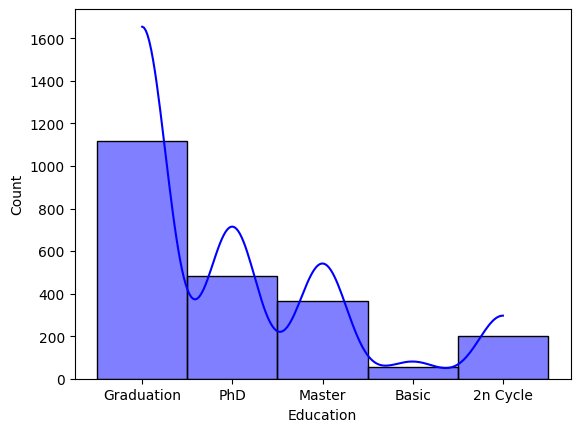

In [15]:
sns.histplot(data["Education"],kde=True,color="Blue")
#Most are graduated adults

<Axes: xlabel='Marital_Status', ylabel='Count'>

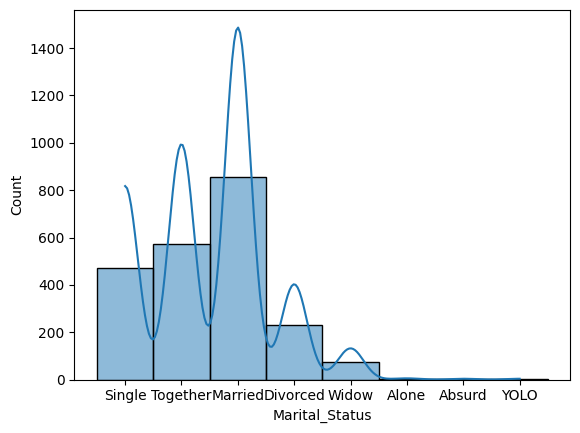

In [16]:
sns.histplot(data["Marital_Status"],kde=True)
#Graduated and married couple are our target as i see

<Axes: xlabel='Education', ylabel='Marital_Status'>

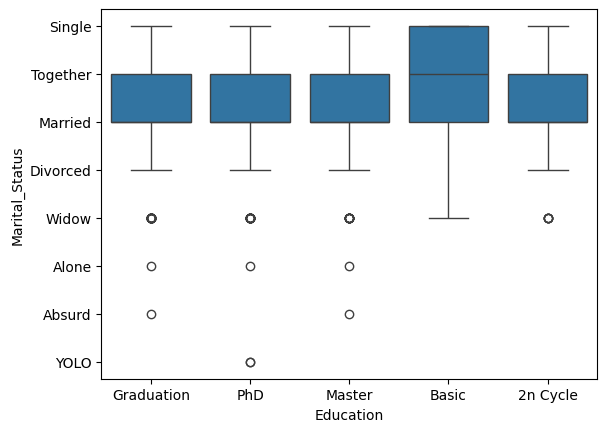

In [17]:
sns.boxplot(x="Education",y="Marital_Status",data=data)

<Axes: xlabel='Income', ylabel='Count'>

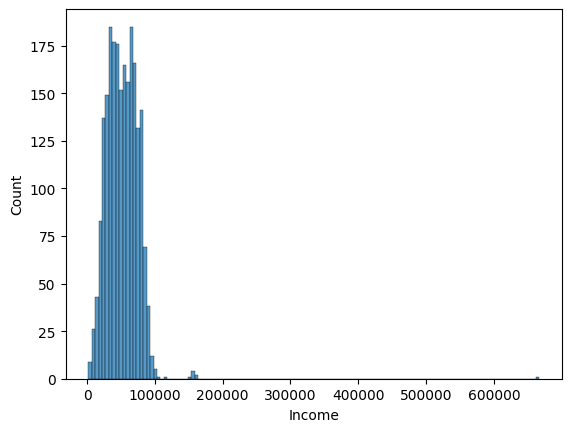

In [18]:
sns.histplot(data["Income"])

<Axes: xlabel='Spending', ylabel='Count'>

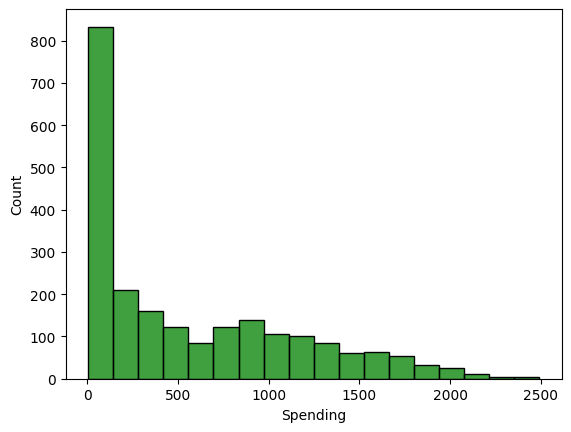

In [19]:
sns.histplot(data["Spending"],color='g')
#Low cost products for Graduated Married couples

<Axes: xlabel='Marital_Status', ylabel='Spending'>

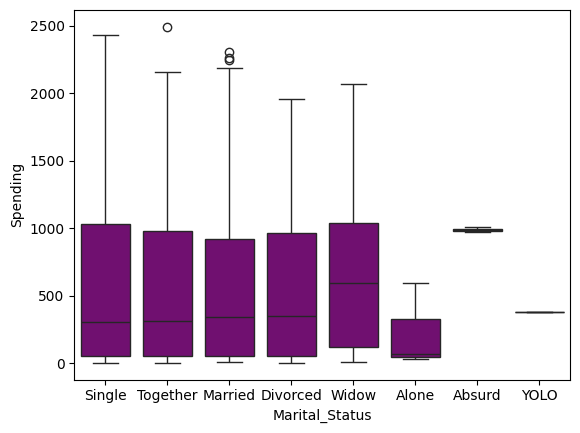

In [20]:
sns.boxplot(x="Marital_Status",y="Spending",data=data,color='purple')
#widows and singles are spending the most
#ppl without another to feed are eating more sheesh

#We are also seeing absurd and yolo is useless for info

In [21]:
# Keeps only rows where Marital_Status is NOT in ['Absurd', 'YOLO']
data = data[~data["Marital_Status"].isin(["Absurd", "YOLO","Alone"])]

In [22]:
data.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1',
       'AcceptedCmp2', 'Complain', 'Z_CostContact', 'Z_Revenue', 'Response',
       'Age', 'Totchild', 'Spending', 'Customer_since'],
      dtype='object')

In [23]:
corr=data[["Income","Recency","Spending",'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases']].corr()

<Axes: >

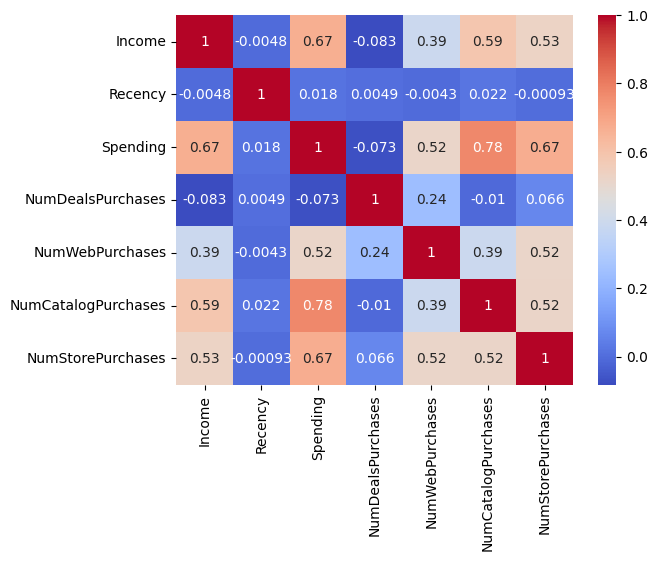

In [24]:
sns.heatmap(corr,annot=True,cmap="coolwarm")

In [25]:
pvt= data.pivot_table(values="Income",index="Education",columns="Marital_Status",aggfunc= "mean")

Text(0.5, 1.0, 'Average Income By Marital Status and Education')

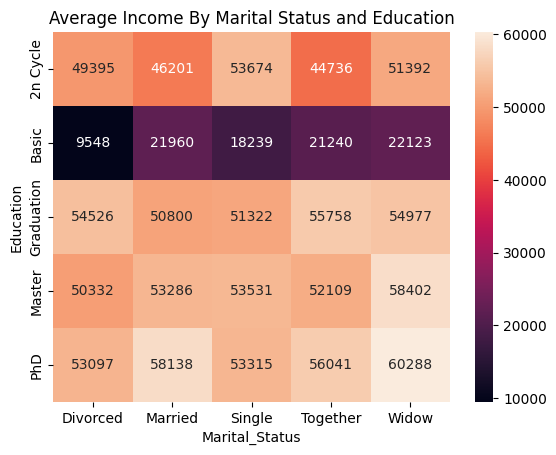

In [26]:
sns.heatmap(pvt,annot=True,fmt='0.0f')
plt.title("Average Income By Marital Status and Education")

In [27]:
gp1=data.groupby("Education")["Spending"].mean().sort_values(ascending=False)
gp1

,Spending
Education,
PhD,646.715481
Graduation,571.094255
Master,568.316804
2n Cycle,448.050000
Basic,58.962963


<Axes: xlabel='Education'>

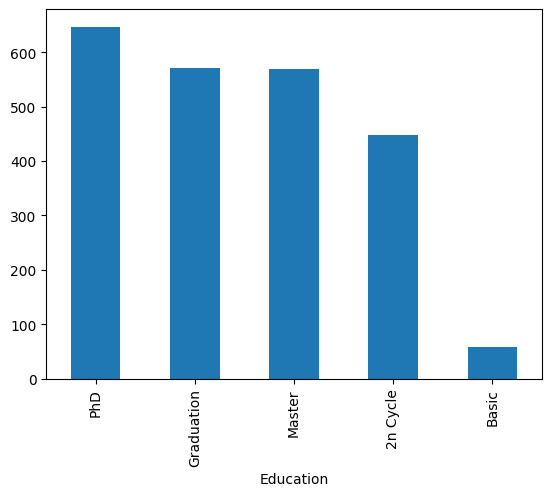

In [28]:
gp1.plot(kind="bar")

In [29]:
gp1=data.groupby("Marital_Status")["Spending"].mean().sort_values(ascending=False)
gp1

,Spending
Marital_Status,
Widow,672.105263
Single,569.286624
Together,565.645724
Divorced,564.340517
Married,548.618436


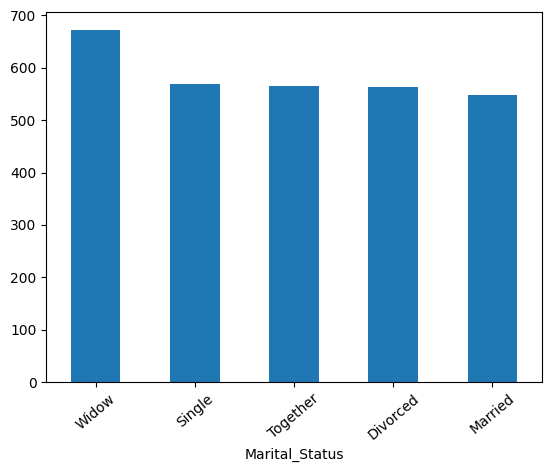

In [30]:
gp1.plot(kind="bar")
plt.xticks(rotation=40)
plt.show()


In [31]:
data["Acceptedany"]=data[['AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1', 'AcceptedCmp2']].sum(axis=1)

In [32]:
data["Acceptedany"].unique()

array([0, 1, 2, 3, 4])

In [33]:
data["Acceptedany"]=data["Acceptedany"].apply(lambda x:1 if x>0 else 0 )

In [34]:
grp2=data.groupby("Marital_Status")["Acceptedany"].mean().sort_values(ascending=False)
grp2

,Acceptedany
Marital_Status,
Widow,0.236842
Married,0.211202
Single,0.205945
Together,0.200698
Divorced,0.198276


<Axes: xlabel='Marital_Status'>

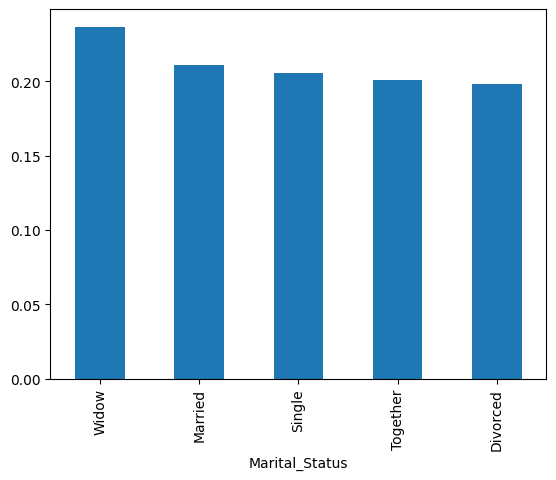

In [35]:
grp2.plot(kind="bar")

In [36]:
#lets do the age group check
bins=[18,30,40,50,60,70,90]
labels=["18-29","30-39","40-49","50-59","60-69","70+"]
data["AgeGroup"]=pd.cut(data["Age"],bins=bins,labels=labels)

In [37]:
grp3=data.groupby("AgeGroup")["Age"].mean().sort_values(ascending=False)
grp3

/tmp/ipykernel_13671/3793824189.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grp3=data.groupby("AgeGroup")["Age"].mean().sort_values(ascending=False)


,Age
AgeGroup,
70+,75.002770
60-69,65.385093
50-59,55.057778
40-49,46.310757
30-39,37.311475
18-29,30.000000


<Axes: xlabel='AgeGroup'>

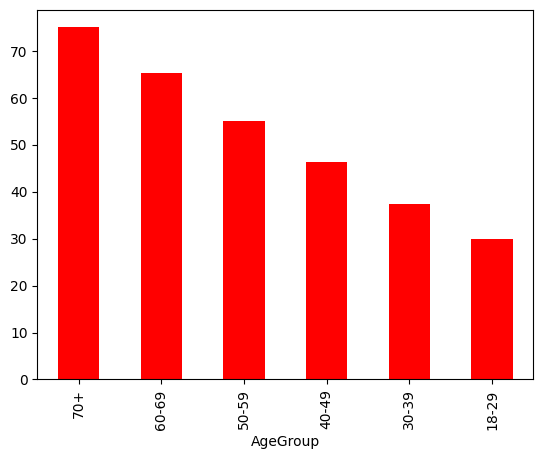

In [38]:
grp3.plot(kind="bar",color="r")

/tmp/ipykernel_13671/2361056416.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grp4=data.groupby("AgeGroup")["Income"].mean().sort_values(ascending=False)


<Axes: ylabel='AgeGroup'>

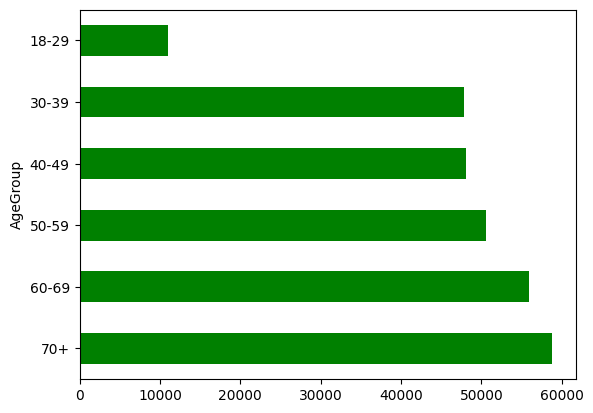

In [39]:
grp4=data.groupby("AgeGroup")["Income"].mean().sort_values(ascending=False)
grp4.plot(kind="barh",color="g")

#Filtering


In [40]:
data.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1',
       'AcceptedCmp2', 'Complain', 'Z_CostContact', 'Z_Revenue', 'Response',
       'Age', 'Totchild', 'Spending', 'Customer_since', 'Acceptedany',
       'AgeGroup'],
      dtype='object')

In [41]:
features=['Age','Income','Spending','NumStorePurchases','Recency','NumWebPurchases','NumWebVisitsMonth']

In [42]:
X=data[features].copy()
X.head()

,Age,Income,Spending,NumStorePurchases,Recency,NumWebPurchases,NumWebVisitsMonth
0,69,58138.0,1529,4,58,8,7
1,72,46344.0,21,2,38,1,5
2,61,71613.0,734,10,26,8,4
3,42,26646.0,48,4,26,2,6
4,45,58293.0,407,6,94,5,5


In [43]:
#as we have different rate
from sklearn.preprocessing import StandardScaler
ss=StandardScaler()

In [44]:
X_ss=ss.fit_transform(X)
X_ss

array([[ 0.98558604,  0.23395688,  1.67187133, ...,  0.30834302,
         1.43081796,  0.6936593 ],
       [ 1.23604538, -0.23419328, -0.93897164, ..., -0.38270322,
        -1.12547761, -0.13148523],
       [ 0.31769447,  0.76883252,  0.29546539, ..., -0.79733096,
         1.43081796, -0.5440575 ],
       ...,
       [-1.01808869,  0.18803101,  1.13169692, ...,  1.4485693 ,
        -0.76029253,  0.28108704],
       [ 1.06907249,  0.67483731,  0.37856914, ..., -1.41927257,
         0.7004478 , -0.95662977],
       [ 1.23604538,  0.02480958, -0.71389897, ..., -0.3135986 ,
        -0.39510744,  0.6936593 ]])

In [45]:
#so as we saw in theory, we need to know how many clusters are needed
#so we use elbow method in KMeans
from sklearn.cluster import KMeans
#simple loop works
ws=[]
for i in range (2,10):
  km=KMeans(n_clusters=i)
  km.fit_transform(X_ss)
  ws.append(km.inertia_)

In [46]:
ws

[10202.23651793904,
 9005.262687334001,
 8154.863922660255,
 7709.516470191406,
 7092.985101678931,
 6851.004640162952,
 6508.097877694766,
 5883.575492225929]

Text(0.5, 0, 'Number of clusters')

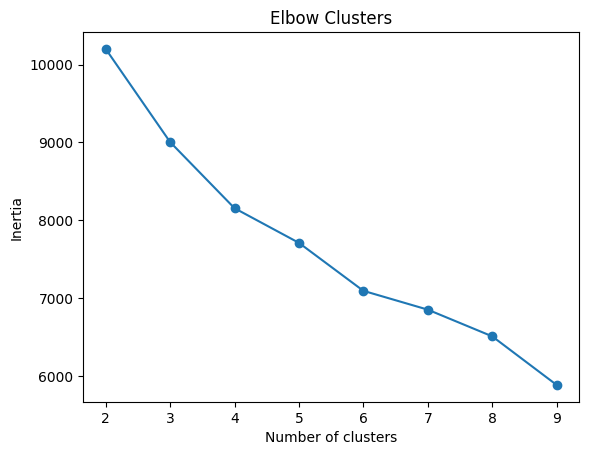

In [47]:
plt.plot(range(2,10),ws,marker='o')
plt.title("Elbow Clusters")
plt.ylabel("Inertia")
plt.xlabel("Number of clusters")
#i like 4 and 6, though i will take a note that when its (1,10) 2 made the best elbow

In [48]:
km=KMeans(n_clusters=6)
data["Clusters"]=km.fit_predict(X_ss)
data["Clusters"]


,Clusters
0,1
1,2
2,1
3,4
4,5
...,...
2235,1
2236,1
2237,3
2238,0


In [49]:
cs=data.groupby("Clusters")[features].mean()
cs

,Age,Income,Spending,NumStorePurchases,Recency,NumWebPurchases,NumWebVisitsMonth
Clusters,,,,,,,
0,70.340491,73493.846626,1128.392638,8.530675,53.119632,4.677914,2.754601
1,59.763285,59902.487923,823.427536,7.922705,45.944444,7.949275,6.415459
2,69.824818,43967.817518,154.069343,4.047445,39.266423,2.609489,5.459854
3,47.279635,78365.945289,1239.638298,8.568389,49.313070,4.610942,2.671733
4,48.906040,31669.928412,86.351230,3.111857,26.637584,2.125280,6.843400
5,52.797136,34993.525060,112.200477,3.431981,79.190931,2.431981,6.589499


In [67]:
data["Clusters"].value_counts()

,count
Clusters,
4,447
5,419
1,414
3,329
0,326
2,274


In [53]:
from sklearn.decomposition import PCA
pca=PCA(n_components=2)
pca_d=pca.fit_transform(X_ss)
data["PCA1"],data["PCA2"]=pca_d[:,0],pca_d[:,1]

Text(0.5, 1.0, 'Customer Segmentation')

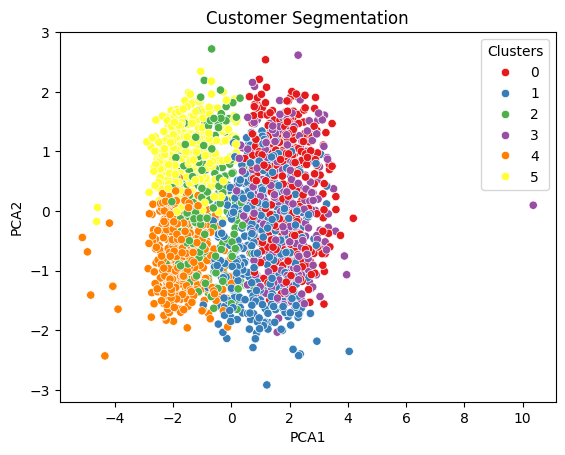

In [64]:
sns.scatterplot(x="PCA1",y="PCA2",data=data,hue="Clusters",palette="Set1")
plt.title("Customer Segmentation")

#Analysis

0) Highest Age
1) Highest WebPurchases
2) High and Recency
3) Highest Income and Spending
4) Lowest Spending and Highest Visits
5) Average Most